In [10]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt


In [11]:
givenWkdir = ''
df_optimumK=pd.read_csv("BestKvalueCluster_VT.csv")
df_ssdeepClusters=pd.read_csv("/home/mabon/research/Autoyara/YaraResults/clusterCSV/ssdeep/th50.csv")
df_ssdeepClusters['File_Path'] = df_ssdeepClusters['File_Path'].str.replace('/usr/src/app/', givenWkdir, regex=False)
df_vtfam=pd.read_csv("/home/mabon/research/Autoyara/YaraResults/clusterCSV/virusTotal/MainVtCluster.csv")
df_vtfam['File_Path'] = df_vtfam['File_Path'].str.replace('/mnt/data_disk1/mabon/', givenWkdir, regex=False)
unique_paths_b = df_vtfam['File_Path'].unique()
df_ssdeepClusters=df_ssdeepClusters[df_ssdeepClusters['File_Path'].isin(unique_paths_b)]

In [12]:
from tqdm import tqdm
import os
import pandas as pd

# Step 2: Function to extract file name from File_Path
def extract_file_name(file_path):
    return os.path.basename(file_path)

# Initialize lists to store new DataFrame data
result_data = {
    'File_Name': [],
    'Cluster_Label_A': [],
    'Cluster_Label_B': [],
    'File_Path_A': [],
    'File_Path_B': []
}

# Group File_Path by Cluster_Label in Dataframe A
cluster_paths = df_ssdeepClusters.groupby('Cluster_Label')['File_Path'].apply(list).to_dict()

# Iterate through each Cluster_Label and File_Path in Dataframe A
for cluster_label, paths in tqdm(cluster_paths.items(), desc="Processing Clusters"):
    for path in paths:
        file_name = extract_file_name(path)
        # Find matching row in Dataframe B
        matching_row = df_vtfam[df_vtfam['File_Name'] == file_name]
        if not matching_row.empty:
            # Match found, append data
            result_data['File_Name'].append(file_name)
            result_data['Cluster_Label_A'].append(cluster_label)
            result_data['Cluster_Label_B'].append(matching_row['Cluster_Label'].iloc[0])
            result_data['File_Path_A'].append(path)
            result_data['File_Path_B'].append(matching_row['File_Path'].iloc[0])
        else:
            # No match, append with None for Dataframe B columns
            result_data['File_Name'].append(file_name)
            result_data['Cluster_Label_A'].append(cluster_label)
            result_data['Cluster_Label_B'].append(None)
            result_data['File_Path_A'].append(path)
            result_data['File_Path_B'].append(None)
# Create new DataFrame
df_result = pd.DataFrame(result_data)


Processing Clusters: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28727/28727 [01:53<00:00, 252.73it/s]


In [13]:
df_result

,File_Name,Cluster_Label_A,Cluster_Label_B,File_Path_A,File_Path_B
0,a470823db33706bd6ea4768a5240e82815fac99ce26dbd...,0,1046,datacopy/evasive-it/2021/a470823db33706bd6ea47...,datacopy/evasive-it/2021/a470823db33706bd6ea47...
1,07a8958e9a5969c1643093bc114def0d985685e7b34eba...,0,1046,datacopy/evasive-it/2021/07a8958e9a5969c164309...,datacopy/evasive-it/2021/07a8958e9a5969c164309...
2,55a3c455cfbd70fd91663e251ea65db6452edbb0d730c8...,1,312,datacopy/evasive-it/2021/55a3c455cfbd70fd91663...,datacopy/evasive-it/2021/55a3c455cfbd70fd91663...
3,b9c705cedc02d6ef6ea1764f6dfb0724ce66c878f5c033...,1,312,datacopy/evasive-it/2021/b9c705cedc02d6ef6ea17...,datacopy/evasive-it/2021/b9c705cedc02d6ef6ea17...
4,Trojan.Win32.Bublik.aeld-736c814b6d4979459e0e3...,1,312,datacopy/evasive-it/2022/Trojan.Win32.Bublik.a...,datacopy/evasive-it/2022/Trojan.Win32.Bublik.a...
...,...,...,...,...,...
44635,c18d502e29a7a9bc73a6b14a8d49a5163a8695ed81a8dc...,37639,1001,datacopy/Stefano/c18d502e29a7a9bc73a6b14a8d49a...,datacopy/Stefano/c18d502e29a7a9bc73a6b14a8d49a...
44636,e51d3eb09f24de89b8f1615fb7eb7ba2f57581b79469e3...,37640,819,datacopy/Stefano/e51d3eb09f24de89b8f1615fb7eb7...,datacopy/Stefano/e51d3eb09f24de89b8f1615fb7eb7...
44637,35b0b54eff0b4fb3ff9da9dfb3f85b1c6d75aa618e475a...,37641,642,datacopy/Stefano/35b0b54eff0b4fb3ff9da9dfb3f85...,datacopy/Stefano/35b0b54eff0b4fb3ff9da9dfb3f85...
44638,b0faac097178e37320f1efc7beeab100f8b18f5c67936e...,37642,1224,datacopy/Stefano/b0faac097178e37320f1efc7beeab...,datacopy/Stefano/b0faac097178e37320f1efc7beeab...


In [4]:
# Create mapping from cluster number to best_k_value
k_map = df_optimumK.set_index('cluster_number')['best_k_value']

# Map and convert to int (after handling NaNs if any)
df_result['best_k_value'] = df_result['Cluster_Label_B'].map(k_map)

# Fill missing values with a default (e.g., 1), then convert to int
df_result['best_k_value'] = df_result['best_k_value'].fillna(1).astype(int)

In [5]:
df=df_result

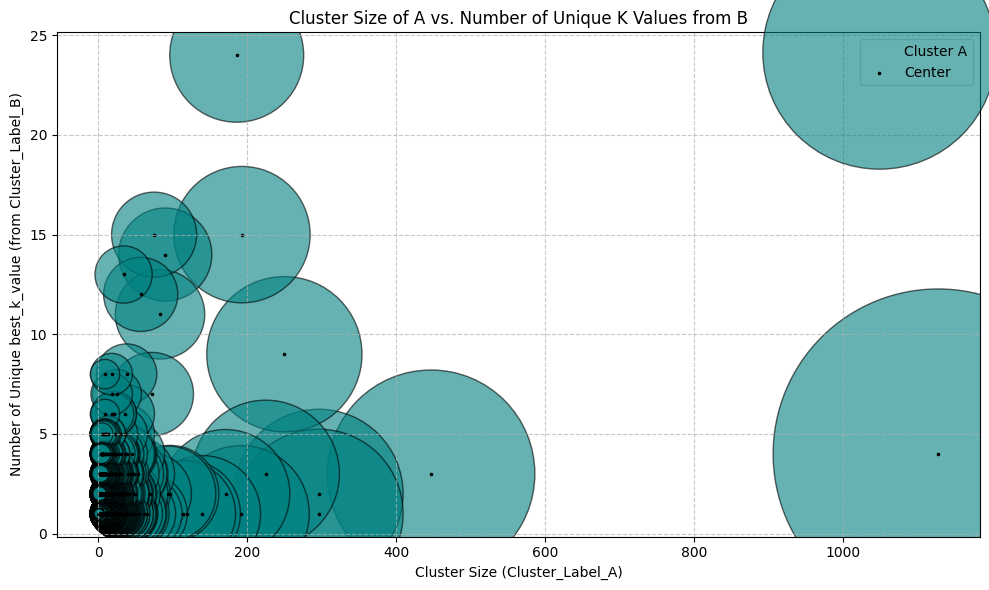

In [6]:

# Calculate cluster size for Cluster_Label_A
cluster_a_sizes = df['Cluster_Label_A'].value_counts().reset_index()
cluster_a_sizes.columns = ['Cluster_Label_A', 'Cluster_Size']

# Group by Cluster_Label_A and Cluster_Label_B to get unique best_k_value counts
k_value_counts = df.groupby('Cluster_Label_A')['Cluster_Label_B'].apply(lambda x: df[df['Cluster_Label_B'].isin(x)]['best_k_value'].nunique()).reset_index(name='Unique_K_Values')

# Merge the two dataframes
plot_data = pd.merge(cluster_a_sizes, k_value_counts, on='Cluster_Label_A')

# Scale point sizes based on Cluster_Size (adjust scaling factor as needed)
point_sizes = plot_data['Cluster_Size'] * 50

# Create a scatter plot
plt.figure(figsize=(10, 6))
# Plot main circles (scaled by cluster size)
plt.scatter(plot_data['Cluster_Size'], plot_data['Unique_K_Values'], s=point_sizes, alpha=0.6, c='teal', edgecolors='black', label='Cluster A')
# Plot center markers (small black dots)
plt.scatter(plot_data['Cluster_Size'], plot_data['Unique_K_Values'], s=10, c='black', marker='.', label='Center')
plt.xlabel('Cluster Size (Cluster_Label_A)')
plt.ylabel('Number of Unique best_k_value (from Cluster_Label_B)')
plt.title('Cluster Size of A vs. Number of Unique K Values from B')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

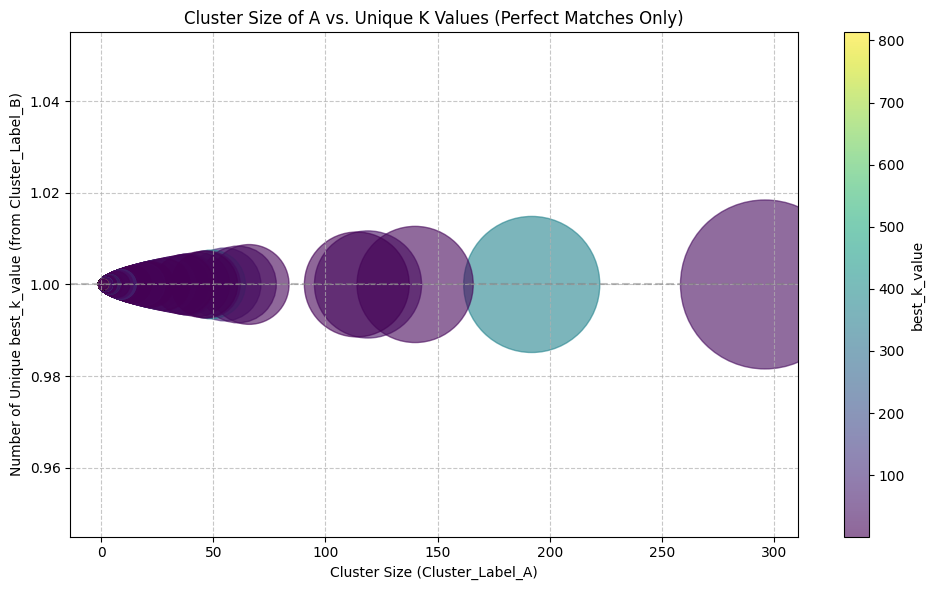

In [7]:
# Step 1: Group by Cluster_Label_A and check if all best_k_value are identical
k_value_counts = df.groupby('Cluster_Label_A').agg({
    'best_k_value': lambda x: x.nunique(),  # Count unique k-values
    'Cluster_Label_A': 'count'  # Count occurrences (cluster size)
}).rename(columns={'Cluster_Label_A': 'Cluster_Size', 'best_k_value': 'Unique_K_Values'}).reset_index()

# Step 2: Filter for Cluster_Label_A where all best_k_value are identical (Unique_K_Values == 1)
perfect_match_clusters = k_value_counts[k_value_counts['Unique_K_Values'] == 1]

# Step 3: Merge with the actual best_k_value for visualization (to color points)
k_values = df.groupby('Cluster_Label_A')['best_k_value'].first().reset_index()
plot_data = pd.merge(perfect_match_clusters, k_values, on='Cluster_Label_A')

# Step 4: Create a scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    plot_data['Cluster_Size'], 
    plot_data['Unique_K_Values'], 
    s=plot_data['Cluster_Size'] * 50,  # Scale point size by cluster size
    c=plot_data['best_k_value'],      # Color by best_k_value
    cmap='viridis', 
    alpha=0.6
)
plt.colorbar(label='best_k_value')
plt.xlabel('Cluster Size (Cluster_Label_A)')
plt.ylabel('Number of Unique best_k_value (from Cluster_Label_B)')
plt.title('Cluster Size of A vs. Unique K Values (Perfect Matches Only)')
plt.axhline(y=1, color='gray', linestyle='--', alpha=0.5)  # Highlight y=1
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [8]:
# Assuming df is your DataFrame
# Step 1: Count elements per Cluster_Label_A
cluster_counts = df['Cluster_Label_A'].value_counts().to_dict()

# Step 2: Filter rows where best_k_value >= cluster size
mask = df.apply(lambda row: row['best_k_value'] >= cluster_counts[row['Cluster_Label_A']], axis=1)

# Step 3: Drop those rows
df_filtered = df[~mask].reset_index(drop=True)

In [9]:
df_filtered

,File_Name,Cluster_Label_A,Cluster_Label_B,File_Path_A,File_Path_B,best_k_value
0,55a3c455cfbd70fd91663e251ea65db6452edbb0d730c8...,1,312,datacopy/evasive-it/2021/55a3c455cfbd70fd91663...,datacopy/evasive-it/2021/55a3c455cfbd70fd91663...,1
1,b9c705cedc02d6ef6ea1764f6dfb0724ce66c878f5c033...,1,312,datacopy/evasive-it/2021/b9c705cedc02d6ef6ea17...,datacopy/evasive-it/2021/b9c705cedc02d6ef6ea17...,1
2,Trojan.Win32.Bublik.aeld-736c814b6d4979459e0e3...,1,312,datacopy/evasive-it/2022/Trojan.Win32.Bublik.a...,datacopy/evasive-it/2022/Trojan.Win32.Bublik.a...,1
3,fcb53d9a6cd9b4e63c21e5a9a32201bf36bdbcc2.bin,1,312,datacopy/UCSB.JP/data_feed.geo_japan_6m_public...,datacopy/UCSB.JP/data_feed.geo_japan_6m_public...,1
4,b9ca6f8b25ffd8fa66194fc826037d667039e830.codex,1,312,datacopy/CodexGiga/b9ca6f8b25ffd8fa66194fc8260...,datacopy/CodexGiga/b9ca6f8b25ffd8fa66194fc8260...,1
...,...,...,...,...,...,...
11412,70f9b23f062ca59cc41c6206634f784c7084305b061c14...,8791,1400,datacopy/Stefano/70f9b23f062ca59cc41c6206634f7...,datacopy/Stefano/70f9b23f062ca59cc41c6206634f7...,1
11413,eeb0a4ee37a2ac836385e23734b15586ec3c7fbaa78069...,8791,1400,datacopy/Stefano/eeb0a4ee37a2ac836385e23734b15...,datacopy/Stefano/eeb0a4ee37a2ac836385e23734b15...,1
11414,cc1e8d22aefa4393c59bdc08f1c03156dca0061b515d11...,8793,1192,datacopy/Stefano/cc1e8d22aefa4393c59bdc08f1c03...,datacopy/Stefano/cc1e8d22aefa4393c59bdc08f1c03...,1
11415,9445d06336861ce91cf5a50b826c377dde8dc8fbda725c...,8793,1192,datacopy/Stefano/9445d06336861ce91cf5a50b826c3...,datacopy/Stefano/9445d06336861ce91cf5a50b826c3...,1


In [18]:
# Group by Cluster_Label_A and transform best_k_value to max within each group
df_filtered['best_k_value'] = df_filtered.groupby('Cluster_Label_A')['best_k_value'].transform('max')


ValueError: Length of values (1993) does not match length of index (11417)

In [16]:
df_filtered=df_filtered.rename(columns={'File_Path_A': 'File_Path'})
df_filtered=df_filtered.drop(columns=['File_Path_B'])


In [31]:
df_filtered.to_csv("Maxk_heuristic_Th50.csv")

In [17]:
df_filtered

,File_Name,Cluster_Label_A,Cluster_Label_B,File_Path,best_k_value
0,55a3c455cfbd70fd91663e251ea65db6452edbb0d730c8...,1,312,datacopy/evasive-it/2021/55a3c455cfbd70fd91663...,1
1,b9c705cedc02d6ef6ea1764f6dfb0724ce66c878f5c033...,1,312,datacopy/evasive-it/2021/b9c705cedc02d6ef6ea17...,1
2,Trojan.Win32.Bublik.aeld-736c814b6d4979459e0e3...,1,312,datacopy/evasive-it/2022/Trojan.Win32.Bublik.a...,1
3,fcb53d9a6cd9b4e63c21e5a9a32201bf36bdbcc2.bin,1,312,datacopy/UCSB.JP/data_feed.geo_japan_6m_public...,1
4,b9ca6f8b25ffd8fa66194fc826037d667039e830.codex,1,312,datacopy/CodexGiga/b9ca6f8b25ffd8fa66194fc8260...,1
...,...,...,...,...,...
11412,70f9b23f062ca59cc41c6206634f784c7084305b061c14...,8791,1400,datacopy/Stefano/70f9b23f062ca59cc41c6206634f7...,1
11413,eeb0a4ee37a2ac836385e23734b15586ec3c7fbaa78069...,8791,1400,datacopy/Stefano/eeb0a4ee37a2ac836385e23734b15...,1
11414,cc1e8d22aefa4393c59bdc08f1c03156dca0061b515d11...,8793,1192,datacopy/Stefano/cc1e8d22aefa4393c59bdc08f1c03...,1
11415,9445d06336861ce91cf5a50b826c377dde8dc8fbda725c...,8793,1192,datacopy/Stefano/9445d06336861ce91cf5a50b826c3...,1
